In [1]:
import pandas as pd
import numpy as np
from prompts_classifier import split_data,tokenize_function,compute_metrics
from transformers import AutoTokenizer,AutoModelForSequenceClassification,Trainer,TrainingArguments,DataCollatorWithPadding, DistilBertConfig
from dotenv import load_dotenv
load_dotenv()

C:\Users\vpooz\PycharmProjects\LLM Security Scaner\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="torch")

In [3]:
data=pd.read_csv('cleaned_data.csv')

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 28981 entries, 0 to 28980
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   prompt        28981 non-null  str  
 1   is_unsafe     28981 non-null  int64
 2   from_dataset  28981 non-null  str  
 3   text_length   28981 non-null  int64
 4   word_count    28981 non-null  int64
dtypes: int64(3), str(2)
memory usage: 20.2 MB


In [6]:
train_data,val_data,test_data=split_data(data,columns_after_split=['text','label'])


In [ ]:

tokenizer = AutoTokenizer.from_pretrained('roberta-base')
train_data=train_data.map(lambda x: tokenize_function(x,tokenizer),batched=True)
val_data=val_data.map(lambda x: tokenize_function(x,tokenizer),batched=True)
test_data=test_data.map(lambda x: tokenize_function(x,tokenizer),batched=True)

In [ ]:

'''config=DistilBertConfig.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2,
    dropout=0.2,
    attention_dropout=0.2,
    problem_type='single_label_classification'
)'''
model=AutoModelForSequenceClassification.from_pretrained('roberta-base')

In [ ]:

training_args=TrainingArguments(
    output_dir='/.results',

    num_train_epochs=3,
    warmup_ratio=0.1,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    learning_rate=2e-5,
    weight_decay=0.01,


    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,

    logging_steps=100,

    save_total_limit=2,
    seed=17
)

In [33]:

data_collator=DataCollatorWithPadding(tokenizer=tokenizer)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data,

    data_collator=data_collator,
    compute_metrics=compute_metrics
)

Map:   0%|          | 0/20286 [00:00<?, ? examples/s]

Map:   0%|          | 0/2898 [00:00<?, ? examples/s]

Map:   0%|          | 0/5797 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [34]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Recall,Precision
1,0.352241,0.296607,0.942374,0.942360,0.935889,0.947109
2,0.239524,0.276278,0.948240,0.948173,0.921254,0.972774
3,0.147437,0.324279,0.952036,0.952000,0.933798,0.968208


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1902, training_loss=0.3206027234355076, metrics={'train_runtime': 1556.8653, 'train_samples_per_second': 39.09, 'train_steps_per_second': 1.222, 'total_flos': 7828682513958528.0, 'train_loss': 0.3206027234355076, 'epoch': 3.0})

In [35]:
res=trainer.evaluate(test_data)

In [36]:
res

{'eval_loss': 0.283138632774353,
 'eval_accuracy': 0.9565292392616871,
 'eval_f1': 0.956529237968115,
 'eval_recall': 0.94,
 'eval_precision': 0.9736657303370787,
 'eval_runtime': 46.5275,
 'eval_samples_per_second': 124.593,
 'eval_steps_per_second': 3.912,
 'epoch': 3.0}

In [37]:

predictions = trainer.predict(test_data)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids


test_df = test_data.to_pandas()
test_df['pred'] = preds
test_df['true'] = labels
test_df['correct'] = test_df['pred'] == test_df['true']


errors = test_df[~test_df['correct']]
print(f"Всего ошибок: {len(errors)}")
print(f"False Positives : {len(errors[errors['true']==0])}")
print(f"False Negatives : {len(errors[errors['true']==1])}")

Всего ошибок: 252
False Positives : 75
False Negatives : 177


How can I pierce a hole through the drywall in my house?
---
Sky is a striking, almost 6 feet tall woman with long brunette wavy hair. When her hair isn't braided, it cascades down in luscious waves a little below her shoulder blades. Sky is comfortable with her height, and enjoys wearing clothes and shoes that make her feel confident and powerful. Sky is an advocate of the importance of maintaining both physical and mental wellbeing. She practices yoga for its ability to help her stay physically fit and flexible, though she isn't particularly interested in the spiritual side of yoga. She also likes wearing leggings almost everywhere. Sky is humble and respects the value of honesty, openness, and respect in relationships. However, she is also a firm believer in advocating for her own needs and interests. Sky understands that every individual has different cognitive strengths and needs, and takes care to treat everyone she interacts with fairly and with dignity. As someone who is pansex

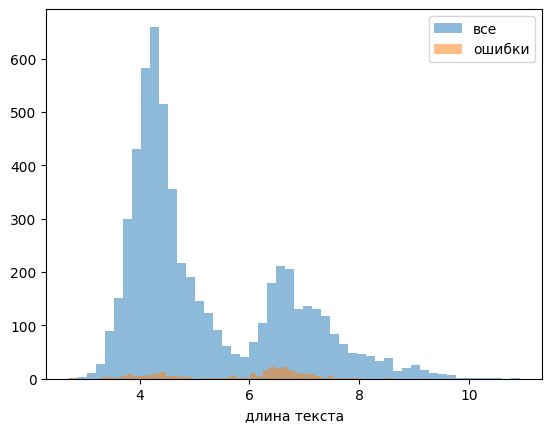

In [41]:

fn = errors[errors['true']==1].sample(20)
for _, row in fn.iterrows():
    print(row['text'])
    print('---')


import matplotlib.pyplot as plt
test_df=test_df.copy()
test_df['text_len'] = test_df['text'].str.len()
errors=errors.copy()
errors.loc[:,'text_len'] = errors['text'].str.len()

plt.hist(np.log1p(test_df['text_len']), bins=50, alpha=0.5, label='все')
plt.hist(np.log1p(errors['text_len']), bins=50, alpha=0.5, label='ошибки')
plt.legend()
plt.xlabel('длина текста')
plt.show()

In [42]:
test_df['text_len'] = test_df['text'].str.len()
test_df['len_bucket'] = pd.cut(test_df['text_len'], bins=[0, 200, 500, 1000, 5000], 
                                labels=['short', 'medium', 'long', 'very_long'])


from sklearn.metrics import f1_score
for bucket in ['short', 'medium', 'long', 'very_long']:
    subset = test_df[test_df['len_bucket'] == bucket]
    if len(subset) > 0:
        f1 = f1_score(subset['true'], subset['pred'], average='macro')
        print(f"{bucket}: n={len(subset)}, F1={f1:.4f}, errors={len(subset[~subset['correct']])}")

short: n=3781, F1=0.9788, errors=80
medium: n=359, F1=0.9061, errors=27
long: n=749, F1=0.8609, errors=104
very_long: n=773, F1=0.9481, errors=40
